In [17]:
import pandas as pd

def load_data(file_path):
    """
    Load data from a CSV file into a pandas DataFrame.
    
    Parameters:
    file_path (str): The path to the CSV file.
    
    Returns:
    pd.DataFrame: DataFrame containing the loaded data.
    """
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"An error occurred while loading the data: {e}")
        return None
    

In [18]:
import matplotlib.pyplot as plt

def plot_data(data, x_column, y_column):
    """
    Plot data from a DataFrame.
    
    Parameters:
    data (pd.DataFrame): The DataFrame containing the data to plot.
    x_column (str): The column name for the x-axis.
    y_column (str): The column name for the y-axis.
    """
    try:
        plt.figure(figsize=(10, 6))
        plt.plot(data[x_column], data[y_column], marker='o')
        plt.title(f'{y_column} vs {x_column}')
        plt.xlabel(x_column)
        plt.ylabel(y_column)
        plt.grid()
        plt.show()
    except Exception as e:
        print(f"An error occurred while plotting the data: {e}")
        

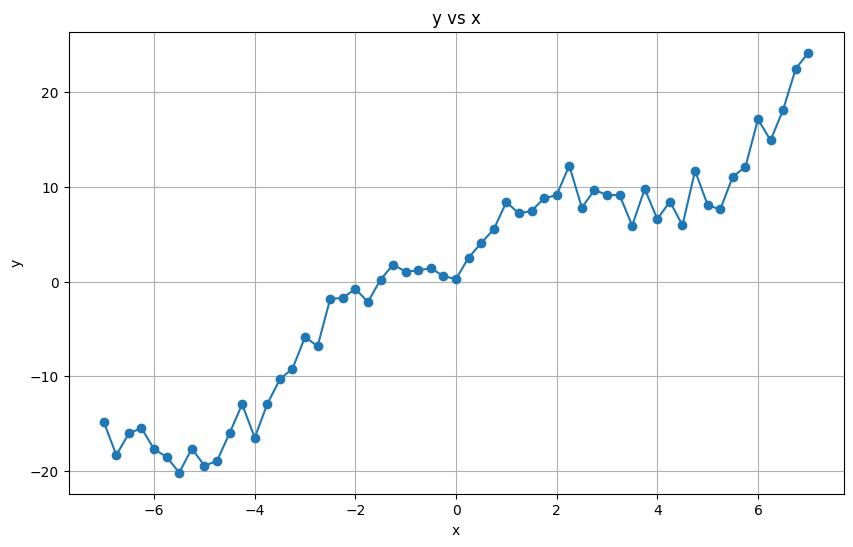

In [19]:
# Load data from a CSV file
data = load_data('NoisyFunction.csv')
plot_data(data, 'x', 'y')  # Assuming the CSV has columns 'x' and 'y'

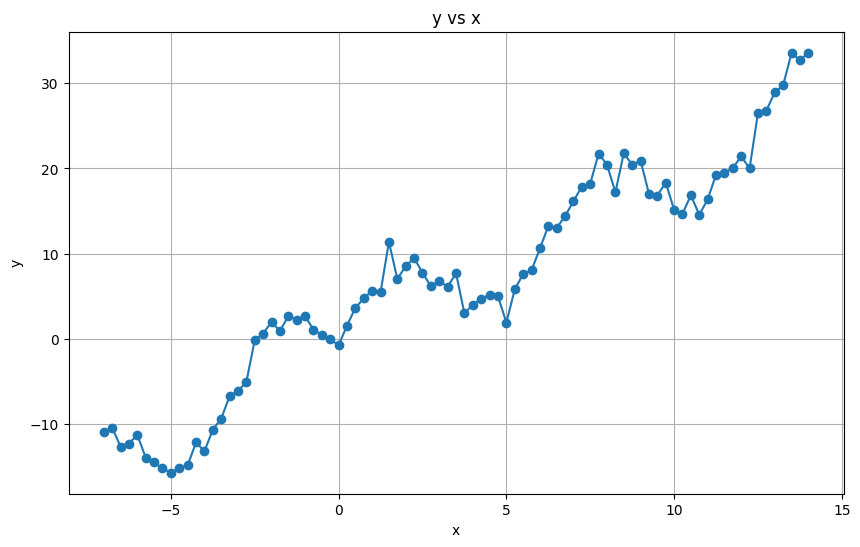

In [20]:
# Load data from a CSV file
data_ext = load_data('NoisyFunction_ext.csv')
plot_data(data_ext, 'x', 'y')  # Assuming the CSV has columns 'x' and 'y'

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def polynomial_regression_and_evaluate(train_data, test_data, x_column, y_column, degree=2):
    # Perform polynomial regression on training data and evaluate on test data
    """    Perform polynomial regression on training data and evaluate on test data.
    
    Parameters:
    train_data (pd.DataFrame): The training data.
    test_data (pd.DataFrame): The test data.
    x_column (str): The column name for the independent variable.
    y_column (str): The column name for the dependent variable.
    degree (int): The degree of the polynomial (default is 2).
    
    Returns:
    tuple: Coefficients, intercept, mean squared error, and R^2 score.
    """
    
    try:
        # Prepare the data
        X_train = train_data[[x_column]].values
        y_train = train_data[y_column].values
        X_test = test_data[[x_column]].values
        y_test = test_data[y_column].values
        
        # Create polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        # Create and fit the model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_poly)
        
        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        return model.coef_, model.intercept_, mse, r2
    except Exception as e:
        print(f"An error occurred during polynomial regression: {e}")
        return None, None, None, None

def linear_regression_and_evaluate(train_data, test_data, x_column, y_column):
    """
    Perform linear regression on training data and evaluate on test data.
    
    Parameters:
    train_data (pd.DataFrame): The training data.
    test_data (pd.DataFrame): The test data.
    x_column (str): The column name for the independent variable.
    y_column (str): The column name for the dependent variable.
    
    Returns:
    tuple: Coefficient, intercept, mean squared error, and R^2 score.
    """
    # Prepare the data
    X_train = train_data[[x_column]].to_numpy()
    y_train = train_data[y_column].to_numpy()
    X_test = test_data[[x_column]].to_numpy()
    y_test = test_data[y_column].to_numpy()
    
    # Create and fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return model.coef_[0], model.intercept_, mse, r2

In [22]:
# Split data 60/40
from sklearn.model_selection import train_test_split

[train_data, test_data] = train_test_split(data, test_size=0.4)
linear_coeff, linear_intercept, linear_mse, linear_r2 = linear_regression_and_evaluate(train_data, test_data, 'x', 'y')
[train_data_poly, test_data_poly] = train_test_split(data_ext, test_size=0.4)
poly_coeff, poly_intercept, poly_mse, poly_r2 = polynomial_regression_and_evaluate(train_data_poly, test_data_poly, 'x', 'y', degree=3)
print("Linear Coefficients:", linear_coeff)
print("Linear Intercept:", linear_intercept)
print("Linear Mean Squared Error:", linear_mse)
print("Linear R^2 Score:", linear_r2)
print()
print("Polynomial Coefficients:", poly_coeff)
print("Polynomial Intercept:", poly_intercept)
print("Polynomial Mean Squared Error:", poly_mse)
print("Polynomial R^2 Score:", poly_r2)

Linear Coefficients: 2.6374006477050984
Linear Intercept: -0.199504449865006
Linear Mean Squared Error: 14.35792354705367
Linear R^2 Score: 0.9095513434845444

Polynomial Coefficients: [ 0.          1.81157592 -0.1109762   0.00875527]
Polynomial Intercept: 2.0448570967261865
Polynomial Mean Squared Error: 13.963488517082967
Polynomial R^2 Score: 0.9227053784231665


In [23]:
# Main execution block to demonstrate functionality
coefficients, intercept, mse, r2 = linear_regression_and_evaluate(data, data_ext, 'x', 'y')
print("Coefficients:", coefficients)
print("Intercept:", intercept)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Coefficients: 2.728858229193674
Intercept: 0.3060391228070176
Mean Squared Error: 42.590010573681894
R^2 Score: 0.7401301690630113


In [24]:
coefficients_poly, intercept_poly, mse_poly, r2_poly = polynomial_regression_and_evaluate(data, data_ext, 'x', 'y', degree=3)
print("Polynomial Coefficients:", coefficients_poly)
print("Polynomial Intercept:", intercept_poly)
print("Polynomial Mean Squared Error:", mse_poly)
print("Polynomial R^2 Score:", r2_poly)

Polynomial Coefficients: [ 0.00000000e+00  2.65136328e+00 -8.54694414e-02  2.54603539e-03]
Polynomial Intercept: 1.7518971729786663
Polynomial Mean Squared Error: 21.231222884688048
Polynomial R^2 Score: 0.8704542631637944


In [25]:
def reconstruct_function(coefficients, intercept, x_values):
    """
    Reconstruct the linear function from coefficient and intercept.
    
    Parameters:
    coefficients (array-like): The coefficient(s) of the model.
    intercept (float): The intercept.
    x_values (array-like): The x values to evaluate the model.
    
    Returns:
    array-like: The reconstructed y values.
    """
    return coefficients[0] * x_values + intercept


def reconstruct_polynomial_function(coefficients, intercept, x_values):
    """
    Reconstruct polynomial function from coefficients and intercept.
    
    Parameters:
    coefficients (array-like): Coefficients for increasing powers of x (excluding intercept).
    intercept (float): The intercept term to add.
    x_values (array-like): The x values.
    
    Returns:
    array-like: y values.
    """
    y = sum(c * (x_values ** i) for i, c in enumerate(coefficients)) + intercept
    return y


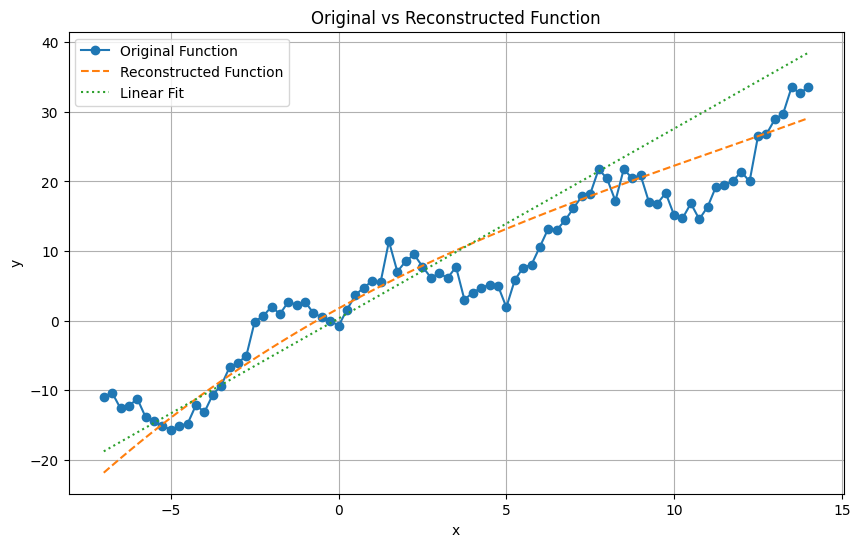

In [26]:
# Compare the original and reconstructed functions
x_values = data_ext['x'].values
y_original = data_ext['y'].values
Y_poly = reconstruct_polynomial_function(coefficients_poly, intercept_poly, x_values)
Y_linear = reconstruct_function([coefficients], intercept, x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_original, label='Original Function', marker='o')
plt.plot(x_values, Y_poly, label='Reconstructed Function', linestyle='--')
plt.plot(x_values, Y_linear, label='Linear Fit', linestyle=':')
plt.title('Original vs Reconstructed Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

Linear+Sine: R²=0.9105, MSE=14.6761
Parameters: Amplitude=11.3797, Frequency=6.3011, Phase=2.6505
Poly+Sine:   R²=0.9173, MSE=13.5582
Parameters: Amplitude=3.9083, Frequency=0.0560, Phase=1.5653


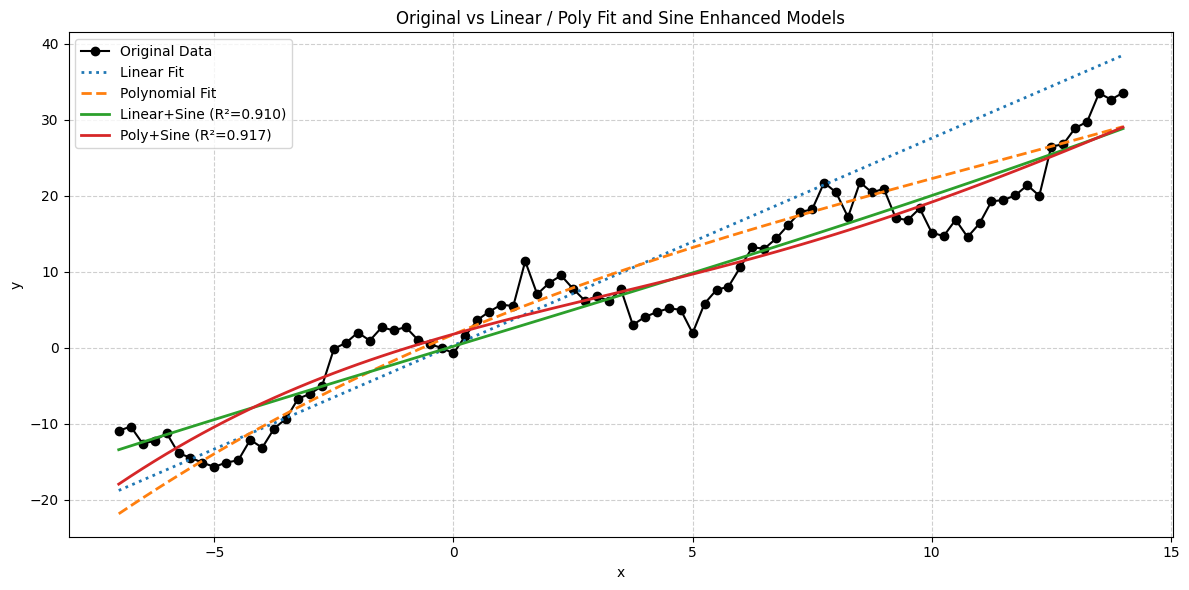

In [27]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def optimize_sine_on_top(base_pred, y_true, swarm_size=150, max_iterations=500):
    """
    Optimize amplitude, frequency, phase of sine wave added on top of base_pred
    to maximize R² or minimize MSE against y_true.
    
    Parameters:
    base_pred (array-like): existing prediction (e.g., linear or poly)
    y_true (array-like): true target values
    
    Returns:
    dict with best params, improved prediction, R² and MSE
    """
    x = np.arange(len(base_pred))
    lower_bound = np.array([-100, 0, 0])           # amplitude, frequency, phase
    upper_bound = np.array([100, 10, 2*np.pi])
    
    inertia = 0.6
    cognitive = 1.4
    social = 1.4
    
    swarm = np.random.uniform(lower_bound, upper_bound, (swarm_size, 3))
    velocities = np.random.uniform(-0.1, 0.1, (swarm_size, 3))
    
    personal_best_positions = swarm.copy()
    personal_best_scores = np.full(swarm_size, np.inf)
    
    global_best_position = None
    global_best_score = np.inf
    
    for iteration in range(max_iterations):
        for i in range(swarm_size):
            amp, freq, phase = swarm[i]
            sine_wave = amp * np.sin(freq * x + phase)
            y_pred = base_pred + sine_wave
            mse = mean_squared_error(y_true, y_pred)
            if mse < personal_best_scores[i]:
                personal_best_scores[i] = mse
                personal_best_positions[i] = swarm[i]
            if mse < global_best_score:
                global_best_score = mse
                global_best_position = swarm[i]
        
        r1 = np.random.rand(swarm_size, 3)
        r2 = np.random.rand(swarm_size, 3)
        velocities = (
            inertia * velocities
            + cognitive * r1 * (personal_best_positions - swarm)
            + social * r2 * (global_best_position - swarm)
        )
        swarm += velocities
        swarm = np.clip(swarm, lower_bound, upper_bound)
    
    # Final prediction
    amp, freq, phase = global_best_position
    sine_wave = amp * np.sin(freq * x + phase)
    improved_pred = base_pred + sine_wave
    final_r2 = r2_score(y_true, improved_pred)
    final_mse = mean_squared_error(y_true, improved_pred)
    
    return {
        'best_params': {'amplitude': amp, 'frequency': freq, 'phase': phase},
        'predicted_y': improved_pred,
        'R2': final_r2,
        'MSE': final_mse
    }

# Fit sine on top of linear regression
result_linear_plus_sine = optimize_sine_on_top(Y_linear, y_original)

# Fit sine on top of polynomial regression
result_poly_plus_sine = optimize_sine_on_top(Y_poly, y_original)

# Print results
print("Linear+Sine: R²=%.4f, MSE=%.4f" % (result_linear_plus_sine['R2'], result_linear_plus_sine['MSE']))
print("Parameters: Amplitude=%.4f, Frequency=%.4f, Phase=%.4f" % (result_linear_plus_sine['best_params']['amplitude'], result_linear_plus_sine['best_params']['frequency'], result_linear_plus_sine['best_params']['phase']))
print("Poly+Sine:   R²=%.4f, MSE=%.4f" % (result_poly_plus_sine['R2'], result_poly_plus_sine['MSE']))
print("Parameters: Amplitude=%.4f, Frequency=%.4f, Phase=%.4f" % (result_poly_plus_sine['best_params']['amplitude'], result_poly_plus_sine['best_params']['frequency'], result_poly_plus_sine['best_params']['phase']))

plt.figure(figsize=(12, 6))
plt.plot(x_values, y_original, label='Original Data', marker='o', color='black')
plt.plot(x_values, Y_linear, label='Linear Fit', linestyle=':', linewidth=2)
plt.plot(x_values, Y_poly, label='Polynomial Fit', linestyle='--', linewidth=2)
plt.plot(x_values, result_linear_plus_sine['predicted_y'], label=f'Linear+Sine (R²={result_linear_plus_sine["R2"]:.3f})', linewidth=2)
plt.plot(x_values, result_poly_plus_sine['predicted_y'], label=f'Poly+Sine (R²={result_poly_plus_sine["R2"]:.3f})', linewidth=2)

plt.title('Original vs Linear / Poly Fit and Sine Enhanced Models')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()